In [2]:
pip install pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


We start by loading the dataset into a Pandas DataFrame so we can explore and analyze the matches.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

#Load dataset
df = pd.read_csv("results.csv")

#Preview first 5 rows
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


We first explore the datatse to understand its size,range of years,uniquie teams and which teams appear most frequently.

In [5]:
# Number of matches
num_matches = df.shape[0]
print("Total matches:", num_matches)

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Earliest and latest match year
earliest_year = df['date'].min().year
latest_year = df['date'].max().year
print("Earliest year:", earliest_year)
print("Latest year:", latest_year)

# Number of unique countries
unique_countries = pd.concat([df['home_team'], df['away_team']]).nunique()
print("Unique countries:", unique_countries)

# Team appearing most as home team
top_home_team = df['home_team'].value_counts().head(1)
print("Team with most home matches:\n", top_home_team)

Total matches: 49071
Earliest year: 1872
Latest year: 2026
Unique countries: 333
Team with most home matches:
 home_team
Brazil    610
Name: count, dtype: int64


We calculate total goals for each match and analyze averages, highest scoring matches, home vs away goals, and common goal totals.

In [6]:
# Create total goals column
df['total_goals'] = df['home_score'] + df['away_score']

# Average goals per match
avg_goals = df['total_goals'].mean()
print("Average goals per match:", round(avg_goals,2))

# Highest scoring match
highest_scoring_match = df.loc[df['total_goals'].idxmax()]
print("Highest scoring match:\n", highest_scoring_match)

# Total goals at home and away
home_goals = df['home_score'].sum()
away_goals = df['away_score'].sum()
print("Total goals scored at home:", home_goals)
print("Total goals scored away:", away_goals)

# Most common total goals value
common_total_goals = df['total_goals'].value_counts().head(1)
print("Most common total goals per match:\n", common_total_goals)

Average goals per match: 2.94
Highest scoring match:
 date                    2001-04-11 00:00:00
home_team                         Australia
away_team                    American Samoa
home_score                               31
away_score                                0
tournament     FIFA World Cup qualification
city                          Coffs Harbour
country                           Australia
neutral                               False
total_goals                              31
Name: 25420, dtype: object
Total goals scored at home: 86182
Total goals scored away: 58011
Most common total goals per match:
 total_goals
2    10896
Name: count, dtype: int64


We create a new column showing the match outcome (“Home Win”, “Away Win”, “Draw”) and analyze home advantage and the top winning countries.

In [7]:
# Function to define match result
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)

# Percentage of matches that are home wins
home_win_pct = (df['result'] == "Home Win").mean() * 100
print("Percentage of home wins:", round(home_win_pct,2))

# Check home advantage
outcome_pct = df['result'].value_counts(normalize=True) * 100
print("Match outcomes percentage:\n", round(outcome_pct,2))

# Determine winner team for each match
def winner(row):
    if row['home_score'] > row['away_score']:
        return row['home_team']
    elif row['home_score'] < row['away_score']:
        return row['away_team']
    else:
        return None

df['winner'] = df.apply(winner, axis=1)

# Country with most wins historically
top_winning_team = df['winner'].value_counts().head(1)
print("Country with most wins:\n", top_winning_team)

Percentage of home wins: 49.0
Match outcomes percentage:
 result
Home Win    49.00
Away Win    28.27
Draw        22.73
Name: proportion, dtype: float64
Country with most wins:
 winner
Brazil    669
Name: count, dtype: int64


Visualizations help us understand the data trends more clearly: distribution of goals, match outcome counts, and top 10 winning teams.

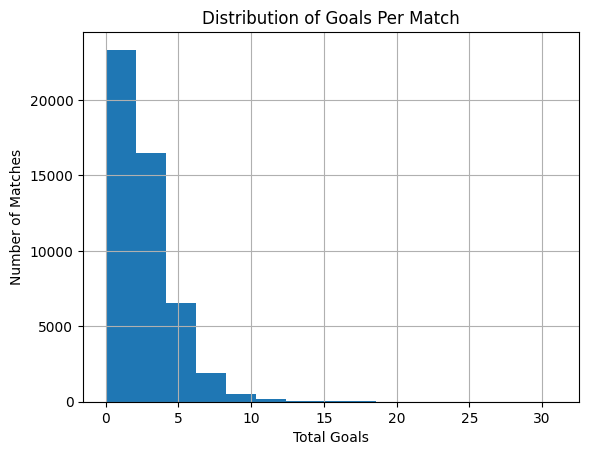

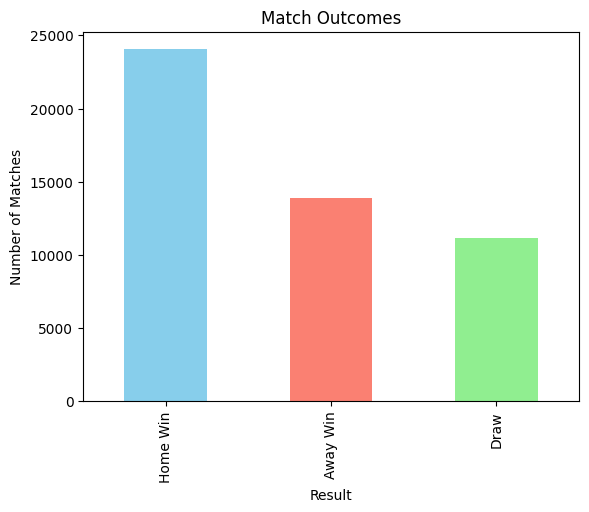

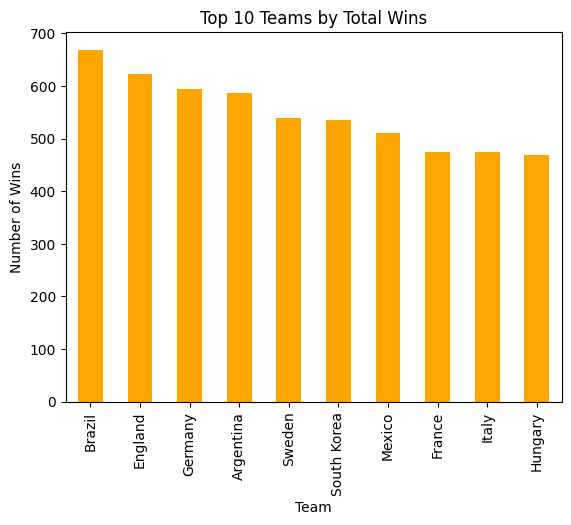

In [8]:
# Histogram of total goals
df['total_goals'].hist(bins=15)
plt.title("Distribution of Goals Per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.show()

# Bar chart of match outcomes
df['result'].value_counts().plot(kind='bar', color=['skyblue','salmon','lightgreen'])
plt.title("Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

# Top 10 teams by total wins
top_10_teams = df['winner'].value_counts().head(10)
top_10_teams.plot(kind='bar', color='orange')
plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.show()